In [48]:
from joblib import Parallel, delayed
from tqdm.notebook import tqdm

import sys
import pickle
import numpy as np
import pandas as pd
import networkx as nx
import scipy
from itertools import combinations

In [49]:
sys.path.insert(0, "src")

from grn import grn

np.random.seed(5)


In [50]:
G = grn().add_structure(
    n=256,
    k=1,
    alpha=1e-99,
    beta=0.75,       # 1 - 1/r
    gamma=0.25,      # 1/r
    kappa=10,        # --w
    delta_in=100,
    delta_out=1,
)

In [51]:
G.simulate_rna(
    s=1e-4,
    dt=1e-2,
    tmax=20000,
    burnin=5000,
    tol=1e-3,
    save=True,
)


array([[0.40134766, 0.52113436, 0.41345122, 0.55423591, 0.24940203,
        0.00824444, 0.7499939 , 0.05158365, 0.34878561, 0.24131589,
        0.10210803, 0.42921168, 0.43213425, 0.17597388, 0.50327465,
        0.0090051 , 0.84216039, 0.43807547, 0.08892712, 0.00517759,
        0.15249503, 0.00826165, 0.03296733, 0.35410256, 0.025503  ,
        0.02003108, 0.62896421, 0.09378358, 0.37294875, 0.01978424,
        0.26145216, 0.52016119, 0.55319635, 0.59044607, 0.34743717,
        0.21467853, 0.80743297, 0.2937654 , 0.07668098, 0.0138034 ,
        0.41741296, 0.0071455 , 0.32524356, 0.38381767, 0.07250683,
        0.44120831, 0.20507611, 0.00378403, 0.0889725 , 0.05392258,
        0.02707397, 0.19675887, 0.96476643, 0.57437545, 0.02445512,
        0.83692191, 0.02542303, 0.48768259, 0.22263909, 0.0725727 ,
        0.06521748, 0.82519536, 0.1272956 , 0.20865251, 0.25144698,
        0.28727185, 0.09699723, 0.21344278, 0.0803279 , 0.04291328,
        0.29524823, 0.35575755, 0.13498879, 0.01

In [52]:
wt_expression = np.asarray(G.rna).flatten()

wt_df = pd.DataFrame(
    [wt_expression],
    index=["WT"],
    columns=[f"gene_{i}" for i in range(G.n)],
)

wt_df.to_csv("wt_expression.csv")

print("Converged:", G.converged)
print("Expression shape:", wt_expression.shape)
display(wt_df)

Converged: True
Expression shape: (256,)


,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_246,gene_247,gene_248,gene_249,gene_250,gene_251,gene_252,gene_253,gene_254,gene_255
WT,0.401348,0.521134,0.413451,0.554236,0.249402,0.008244,0.749994,0.051584,0.348786,0.241316,...,0.168005,0.044765,0.711097,0.160893,0.122949,0.50253,0.296377,0.721594,0.10093,0.312664


In [53]:
B = G.beta 
x = G.rna.flatten()
l = G.l.flatten()
a = G.alpha.flatten()
    
# jacobian
sig = scipy.special.expit(a + B.T@x.reshape(-1,1))
#sig = (l*x)
A = B.T * (sig * (1 - sig)) - np.diag(l)
evals, evecs = np.linalg.eig(A)
       
# result
stable = all(evals.real < 0)
print(stable)

True


In [54]:
ko_expression = np.zeros((G.n, G.n))
ko_logfc = np.zeros((G.n, G.n))
ko_convergence = {}

for gene in tqdm(range(G.n), desc="Simulating single-gene KOs"):
    
    result = G.ko_nodes(
        genes=[gene],
        stats=("new_rna", 'logfc', 'convergence'),
        s=0,
        dt=1e-2,
        tmax=20000,
        burnin=5000,
        tol=1e-3,
    )
    
    ko_expression[gene, :] = result["new_rna"].flatten()
    ko_logfc[gene, :] = result["logfc"].flatten()
    ko_convergence[gene] = result['convergence']

# Rows = perturbations
# Columns = measured genes
ko_df = pd.DataFrame(
    ko_expression,
    index=[f"KO_{i}" for i in range(G.n)],
    columns=[f"gene_{i}" for i in range(G.n)],
)

fc_ko_df = pd.DataFrame(
    ko_logfc,
    index=[f"KO_{i}" for i in range(G.n)],
    columns=[f"gene_{i}" for i in range(G.n)],
)




# Also save one convenient combined WT + KO matrix
expression_df = pd.concat([wt_df, ko_df])

print("KO matrix shape:", ko_df.shape)
print("Combined matrix shape:", expression_df.shape)

display(expression_df.head())

Simulating single-gene KOs:   0%|          | 0/256 [00:00<?, ?it/s]

KO matrix shape: (256, 256)
Combined matrix shape: (257, 256)


,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_246,gene_247,gene_248,gene_249,gene_250,gene_251,gene_252,gene_253,gene_254,gene_255
WT,0.401348,0.521134,0.413451,0.554236,0.249402,0.008244,0.749994,0.051584,0.348786,0.241316,...,0.168005,0.044765,0.711097,0.160893,0.122949,0.502530,0.296377,0.721594,0.100930,0.312664
KO_0,0.390394,0.260018,0.179904,0.245478,0.268959,0.049882,0.325657,0.032408,0.109815,0.387892,...,0.326616,0.154466,0.633157,0.152132,0.122222,0.502339,0.237886,0.623374,0.100999,0.199634
KO_1,0.564884,0.694178,0.492450,0.512579,0.193463,0.006424,0.841386,0.068035,0.493982,0.123136,...,0.070324,0.052754,0.535470,0.161279,0.117097,0.500635,0.350094,0.503421,0.098717,0.358777
KO_2,0.881548,0.629509,0.982434,0.755017,0.048182,0.006238,0.963061,0.132279,0.195784,0.740172,...,0.051513,0.122232,0.871220,0.161320,0.121017,0.499949,0.133764,0.823938,0.100486,0.136595
KO_3,0.181420,0.370328,0.292336,0.305495,0.296292,0.037791,0.235617,0.047443,0.153522,0.220902,...,0.252342,0.158749,0.508394,0.154632,0.127322,0.502582,0.305236,0.566556,0.102436,0.249536


In [55]:
pairs = np.array(
    list(combinations(range(G.n), 2)),
    dtype=np.int32
)

print("Number of genes:", G.n)
print("Number of double perturbations:", len(pairs))
# For n=200: 19,900

Number of genes: 256
Number of double perturbations: 32640


In [56]:
subset_pairs = pairs

In [57]:
n_jobs = 64

def run_double_ko(pair):
    a, b = pair

    result = G.ko_nodes(
        genes=[a, b],
        stats=("new_rna", "logfc", 'convergence'),
        s=0,
        dt=1e-2,
        tmax=20000,
        burnin=5000,
        tol=1e-3,
    )

    return (
        np.asarray(result["new_rna"]).flatten(),
        np.asarray(result["logfc"]).flatten(),
        np.asarray(result['convergence'])
    )


results = Parallel(
    n_jobs=64,
    pre_dispatch="n_jobs",
    prefer="processes",
    verbose=10,
)(
    delayed(run_double_ko)(pair)
    for pair in pairs
)

double_expression = np.asarray(
    [r[0] for r in results],
    dtype=np.float32
)

double_logfc = np.asarray(
    [r[1] for r in results],
    dtype=np.float32
)
double_convergence = np.asarray(
    [r[2] for r in results],
    dtype=np.float32
)

print("double_expression:", double_expression.shape)
print("double_logfc:", double_logfc.shape)

[Parallel(n_jobs=64)]: Using backend LokyBackend with 64 concurrent workers.
[Parallel(n_jobs=64)]: Done   8 tasks      | elapsed:    0.4s
[Parallel(n_jobs=64)]: Done  21 tasks      | elapsed:    0.5s
[Parallel(n_jobs=64)]: Done  34 tasks      | elapsed:    0.6s
[Parallel(n_jobs=64)]: Done  49 tasks      | elapsed:    0.6s
[Parallel(n_jobs=64)]: Done  64 tasks      | elapsed:    0.7s
[Parallel(n_jobs=64)]: Done  81 tasks      | elapsed:    0.8s
[Parallel(n_jobs=64)]: Done  98 tasks      | elapsed:    0.8s
[Parallel(n_jobs=64)]: Done 117 tasks      | elapsed:    1.0s
[Parallel(n_jobs=64)]: Done 136 tasks      | elapsed:    1.1s
[Parallel(n_jobs=64)]: Done 157 tasks      | elapsed:    1.2s
[Parallel(n_jobs=64)]: Done 178 tasks      | elapsed:    1.3s
[Parallel(n_jobs=64)]: Done 201 tasks      | elapsed:    1.3s
[Parallel(n_jobs=64)]: Done 224 tasks      | elapsed:    1.5s
[Parallel(n_jobs=64)]: Done 249 tasks      | elapsed:    1.6s
[Parallel(n_jobs=64)]: Done 274 tasks      | elapsed:  

double_expression: (32640, 256)
double_logfc: (32640, 256)


In [58]:
for i in double_convergence:
    if i == 1.0:
        continue
    else:
        print(i)

In [59]:
single_logfc = np.asarray(ko_logfc)

single_a = single_logfc[subset_pairs[:, 0], :]
single_b = single_logfc[subset_pairs[:, 1], :]

expected_additive = single_a + single_b

interaction_residuals = double_logfc - expected_additive

print("double KO:", double_logfc.shape)
print("additive expectation:", expected_additive.shape)
print("interaction residuals:", interaction_residuals.shape)

double KO: (32640, 256)
additive expectation: (32640, 256)
interaction residuals: (32640, 256)


In [60]:
errors = interaction_residuals.ravel()

# Just in case a simulation produced zero expression and therefore
# an infinite logFC:
errors = errors[np.isfinite(errors)]

print("Number of residuals:", len(errors))
print("Mean:", errors.mean())
print("SD:", errors.std())

print("Quantiles:")
print(
    np.quantile(
        errors,
        [0, 0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999, 1]
    )
)

Number of residuals: 8355840
Mean: 0.00027597567574407704
SD: 0.026923658044573636
Quantiles:
[-3.10528229e+00 -1.94384008e-01 -4.09881565e-03 -6.66499375e-04
  2.32937809e-05  1.26284750e-03  4.90087165e-03  2.26661891e-01
  4.03301350e+00]


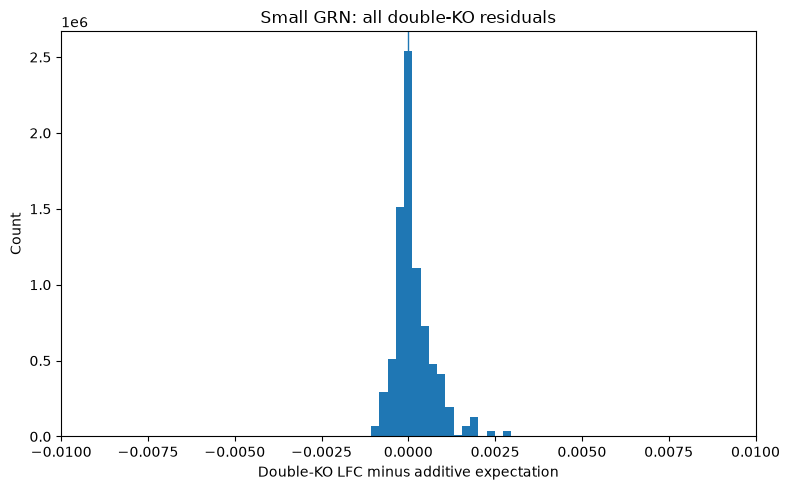

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    errors,
    bins=30000
)

plt.axvline(0, linewidth=1)

plt.xlim(-0.01, 0.01)

plt.xlabel("Double-KO LFC minus additive expectation")
plt.ylabel("Count")
plt.title("Small GRN: all double-KO residuals")

plt.tight_layout()
plt.show()

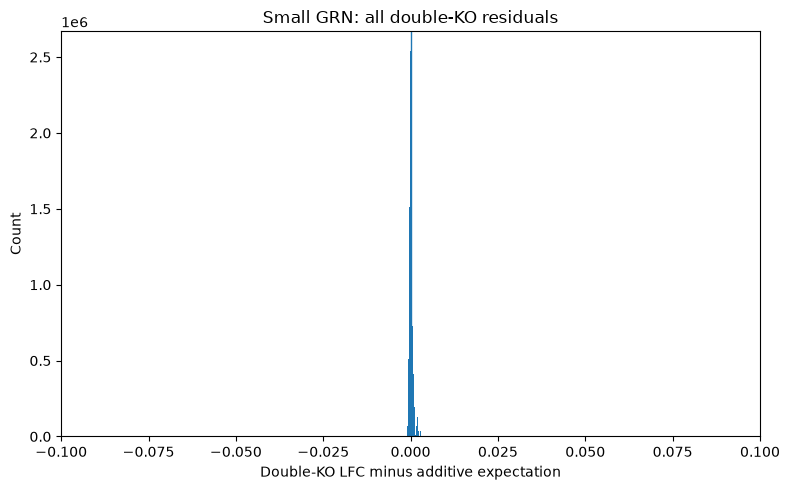

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    errors,
    bins=30000
)

plt.axvline(0, linewidth=1)

plt.xlim(-0.1, 0.1)

plt.xlabel("Double-KO LFC minus additive expectation")
plt.ylabel("Count")
plt.title("Small GRN: all double-KO residuals")

plt.tight_layout()
plt.show()

In [65]:
np.savez_compressed(
    "../../../grn_benchmark/new_data/double_KO_expression.npz",
    pairs=np.asarray(pairs, dtype=np.int64),
    double_expr=np.asarray(double_expression, dtype=np.float32),
)

np.save(
    "../../../grn_benchmark/new_data/single_KO_expression.npy",
    np.asarray(ko_expression, dtype=np.float32),
)

np.save(
    "../../../grn_benchmark/new_data/rna.npy",
    np.asarray(wt_expression, dtype=np.float32).reshape(-1),
)

In [79]:

print(pd.read_csv("../../../grn_benchmark/new_results/test_metrics.csv").to_string(index=False))

p = np.load("../../../grn_benchmark/new_results/test_predictions.npz")
test_pairs = p["pairs"]
observed = p["observed"]
mlp_predictions = p["mlp"]
ridge_predictions = p["ridge"]
additive_predictions = p["additive"]

   model      mse     rmse  mean_l2  standardized_rmse  mse_improvement_over_additive_pct  non_target_gene_rmse  delta_from_wt_pearson  implied_residual_pearson  implied_residual_spearman  large_residual_rmse  fraction_pairs_lower_mse_than_additive  negative_prediction_fraction
      WT 0.032441 0.180114 2.056907           1.973425                        -244.552757              0.180068                    NaN                  0.441657                   0.178307             0.582421                                0.107414                      0.000000
Additive 0.009415 0.097033 0.619820           1.814124                           0.000000              0.096814               0.875339                       NaN                        NaN             0.842321                                0.000000                      0.026101
   Ridge 0.006934 0.083270 0.880718           1.788866                          26.354804              0.083110               0.886625                  0.514329   

In [67]:
import pandas as pd

# Display test_metrics as a formatted Jupyter HTML table
df_metrics = pd.read_csv("../../../grn_benchmark/new_results/test_metrics.csv")
df_metrics

FileNotFoundError: [Errno 2] No such file or directory: '../../../grn_benchmark/new_results/test_metrics.csv'

In [87]:
import json

with open("../../../grn_benchmark/new_results/test_results.json", "r") as f:
  data = json.load(f)
data["bootstrap"]["MLP"]["mse_improvement_pct_ci95"]


[50.96355320109436, 53.949317996468395]

# Lets train MLP on toy 256 gene GRN

In [54]:
n_genes = G.n
n_double = len(pairs)

# X_double[i] contains two 1s: the two genes knocked out
X_double = np.zeros((n_double, n_genes), dtype=np.float32)

rows = np.arange(n_double)
X_double[rows, pairs[:, 0]] = 1.0
X_double[rows, pairs[:, 1]] = 1.0

Y_double = np.asarray(double_expression, dtype=np.float32)

print(X_double.shape)
print(Y_double.shape)

print("Example pair:", pairs[0])
print("Non-zero entries:", np.where(X_double[0] == 1)[0])

(32640, 256)
(32640, 256)
Example pair: [0 1]
Non-zero entries: [0 1]


In [55]:
rng = np.random.default_rng(42)

indices = rng.permutation(n_double)

n_test = int(0.50 * n_double)
n_val  = int(0.10 * n_double)

test_idx = indices[:n_test]
val_idx = indices[n_test:n_test + n_val]
train_idx = indices[n_test + n_val:]

print(
    len(train_idx),
    len(val_idx),
    len(test_idx)
)

13056 3264 16320


In [56]:
X_wt = np.zeros((1, n_genes), dtype=np.float32)
Y_wt = wt_expression.reshape(1, -1).astype(np.float32)

In [57]:
X_single = np.eye(n_genes, dtype=np.float32)
Y_single = np.asarray(ko_expression, dtype=np.float32)

In [58]:
X_train = np.concatenate([
    X_wt,
    X_single,
    X_double[train_idx]
], axis=0)

Y_train = np.concatenate([
    Y_wt,
    Y_single,
    Y_double[train_idx]
], axis=0)

X_val = X_double[val_idx]
Y_val = Y_double[val_idx]

X_test = X_double[test_idx]
Y_test = Y_double[test_idx]

print("train:", X_train.shape, Y_train.shape)
print("val:  ", X_val.shape, Y_val.shape)
print("test: ", X_test.shape, Y_test.shape)

train: (13313, 256) (13313, 256)
val:   (3264, 256) (3264, 256)
test:  (16320, 256) (16320, 256)


In [59]:
y_mean = Y_train.mean(axis=0)
y_std = Y_train.std(axis=0)

# Avoid division by ~zero for nearly invariant genes
y_std = np.maximum(y_std, 1e-6)

Y_train_scaled = (Y_train - y_mean) / y_std
Y_val_scaled   = (Y_val   - y_mean) / y_std
Y_test_scaled  = (Y_test  - y_mean) / y_std

In [63]:
np.save("single_KO_expression.npy", np.asarray(ko_expression))

In [ ]:
linear_model = nn.Linear(256, 256)


In [9]:
import torch
import torch.nn as nn

class PerturbationMLP(nn.Module):
    def __init__(self, n_genes=256):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(n_genes, 512),
            nn.GELU(),

            nn.Linear(512, 512),
            nn.GELU(),

            nn.Linear(512, n_genes)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
#!/usr/bin/env python3
"""Direct-expression GRN benchmark. No graph, residual target, or test-set tuning.

Requires NumPy, SciPy, scikit-learn, and threadpoolctl. The CPU MLP is implemented
explicitly because PyTorch is unavailable in the execution environment.
GPU variant: requires PyTorch. Run: python train_benchmark_gpu.py --data-dir ../upload --output-dir results
"""
from __future__ import annotations

import argparse
import hashlib
import json
import platform
import time
from pathlib import Path

import numpy as np
import scipy
import sklearn
from scipy.special import erf
from sklearn.linear_model import Ridge
from threadpoolctl import threadpool_limits


def dump_json(path, value):
    Path(path).write_text(json.dumps(value, indent=2, allow_nan=False) + "\n")


def multihot(pairs, n_genes):
    x = np.zeros((len(pairs), n_genes), dtype=np.float32)
    x[np.arange(len(pairs))[:, None], pairs] = 1
    return x


def gelu(x):
    return 0.5 * x * (1.0 + erf(x * 0.7071067811865476))


def gelu_derivative(x):
    return (0.5 * (1.0 + erf(x * 0.7071067811865476))
            + x * np.exp(-0.5 * x * x) * 0.3989422804014327)


class DirectExpressionMLP:
    """Multi-hot -> dense/GELU/dropout -> dense/GELU/dropout -> expression.

    All layers, including the output, are learned. No additive skip connection.
    Standardized absolute expression is the target. AdamW decays weights only.
    """
    def __init__(self, n_genes, width=512, dropout=0.1, seed=0, dtype=np.float32):
        self.rng = np.random.default_rng(seed)
        self.dropout = dropout
        self.params = {}
        # PyTorch Linear-style uniform initialization, with zero biases.
        for k, (a, b) in enumerate(zip([n_genes, width, width], [width, width, n_genes])):
            self.params[f"w{k}"] = self.rng.uniform(-1 / np.sqrt(a), 1 / np.sqrt(a), (a, b)).astype(dtype)
            self.params[f"b{k}"] = np.zeros(b, dtype=dtype)
        self.m = {k: np.zeros_like(v) for k, v in self.params.items()}
        self.v = {k: np.zeros_like(v) for k, v in self.params.items()}
        self.step = 0

    def forward(self, x, training=False):
        h, cache = x, []
        for k in range(2):
            z = h @ self.params[f"w{k}"] + self.params[f"b{k}"]
            a = gelu(z)
            mask = None
            if training and self.dropout:
                mask = (self.rng.random(a.shape) >= self.dropout).astype(a.dtype) / (1 - self.dropout)
                a = a * mask
            cache.append((h, z, mask))
            h = a
        pred = h @ self.params["w2"] + self.params["b2"]
        return pred, (cache, h)

    def loss_and_grad(self, x, y, training=True):
        pred, (cache, h) = self.forward(x, training)
        diff = pred - y
        loss = float(np.mean(diff ** 2))
        d = 2.0 * diff / diff.size
        grads = {"w2": h.T @ d, "b2": d.sum(axis=0)}
        d = d @ self.params["w2"].T
        for k in [1, 0]:
            prev, z, mask = cache[k]
            if mask is not None:
                d = d * mask
            d = d * gelu_derivative(z)
            grads[f"w{k}"] = prev.T @ d
            grads[f"b{k}"] = d.sum(axis=0)
            if k:
                d = d @ self.params[f"w{k}"].T
        return loss, grads

    def update(self, grads, lr, weight_decay=1e-4):
        self.step += 1
        b1, b2, eps = 0.9, 0.999, 1e-8
        bc1, bc2 = 1 - b1 ** self.step, 1 - b2 ** self.step
        for k, p in self.params.items():
            g = grads[k]
            self.m[k] *= b1
            self.m[k] += (1 - b1) * g
            self.v[k] *= b2
            self.v[k] += (1 - b2) * g * g
            if k.startswith("w"):
                p *= 1 - lr * weight_decay
            p -= lr * (self.m[k] / bc1) / (np.sqrt(self.v[k] / bc2) + eps)

    def predict(self, x, batch_size=1024):
        return np.concatenate([self.forward(x[i:i + batch_size])[0]
                               for i in range(0, len(x), batch_size)])

    def save(self, path, mean, scale, **metadata):
        np.savez_compressed(path, **self.params, y_mean=mean, y_scale=scale,
                            metadata=np.array(json.dumps(metadata)))


def verify_gradients():
    """Finite differences verify every gradient element on a small dense MLP."""
    rng = np.random.default_rng(7)
    m = DirectExpressionMLP(3, width=4, dropout=0, seed=5, dtype=np.float64)
    x, y = rng.normal(size=(5, 3)), rng.normal(size=(5, 3))
    _, grads = m.loss_and_grad(x, y, training=False)
    errors = []
    for key, param in m.params.items():
        for idx in np.ndindex(param.shape):
            original, eps = param[idx], 1e-5
            param[idx] = original + eps
            plus = m.loss_and_grad(x, y, training=False)[0]
            param[idx] = original - eps
            minus = m.loss_and_grad(x, y, training=False)[0]
            param[idx] = original
            fd = (plus - minus) / (2 * eps)
            errors.append(abs(fd - grads[key][idx]))
    assert max(errors) < 1e-7, max(errors)
    return {"finite_difference_max_absolute_error": float(max(errors)),
            "gradient_elements_checked": len(errors)}


def train_mlp(x, ys, xv, yv, mean, scale, output, dropout, seed, args):
    import torch
    from torch import nn
    torch.manual_seed(seed)
    torch.set_num_threads(args.threads)
    device = torch.device(args.device)
    model = nn.Sequential(nn.Linear(x.shape[1], args.width), nn.GELU(), nn.Dropout(dropout),
                          nn.Linear(args.width, args.width), nn.GELU(), nn.Dropout(dropout),
                          nn.Linear(args.width, x.shape[1])).to(device)
    # Match original initialization; stochastic training trajectories still differ.
    initial = DirectExpressionMLP(x.shape[1], args.width, dropout, seed)
    with torch.no_grad():
        for k, layer in enumerate([model[0], model[3], model[6]]):
            layer.weight.copy_(torch.from_numpy(initial.params[f'w{k}'].T).to(device))
            layer.bias.zero_()
    optimizer = torch.optim.AdamW([
        {'params': [p for name, p in model.named_parameters() if name.endswith('weight')],
         'weight_decay': args.weight_decay},
        {'params': [p for name, p in model.named_parameters() if name.endswith('bias')],
         'weight_decay': 0.0}], lr=args.lr)
    # This small dataset fits on typical GPUs; keep training arrays resident.
    xt = torch.as_tensor(x, dtype=torch.float32, device=device)
    yt = torch.as_tensor(ys, dtype=torch.float32, device=device)
    xvt = torch.as_tensor(xv, dtype=torch.float32, device=device)
    tag = f'mlp_dropout{dropout:g}_seed{seed}'
    checkpoint = output / f'{tag}.npz'
    best, best_epoch, stale, lr_stale = np.inf, 0, 0, 0
    lr, history = args.lr, []
    started = time.perf_counter()
    for epoch in range(1, args.max_epochs + 1):
        model.train()
        permutation = torch.randperm(len(xt), device=device)
        total = torch.zeros((), device=device)
        for start in range(0, len(xt), args.batch_size):
            ii = permutation[start:start + args.batch_size]
            optimizer.zero_grad(set_to_none=True)
            loss = torch.mean((model(xt[ii]) - yt[ii]) ** 2)
            loss.backward()
            optimizer.step()
            total += loss.detach() * len(ii)
        train_loss = float(total.item() / len(xt))
        model.eval()
        with torch.inference_mode():
            val_scaled = torch.cat([model(chunk) for chunk in xvt.split(1024)]).cpu().numpy()
        val_pred = val_scaled.astype(np.float64) * scale + mean
        raw_mse = float(np.mean((val_pred - yv) ** 2))
        if not np.isfinite(train_loss) or not np.isfinite(raw_mse):
            raise FloatingPointError(f'Non-finite loss at epoch {epoch}')
        history.append({'epoch': epoch, 'train_scaled_mse': train_loss,
                        'val_scaled_mse': float(np.mean(((val_pred-yv)/scale)**2)),
                        'val_raw_mse': raw_mse, 'learning_rate': lr,
                        'elapsed_seconds': time.perf_counter()-started})
        if raw_mse < best:
            best, best_epoch, stale, lr_stale = raw_mse, epoch, 0, 0
            weights = {}
            for k, layer in enumerate([model[0], model[3], model[6]]):
                weights[f'w{k}'] = layer.weight.detach().cpu().numpy().T.copy()
                weights[f'b{k}'] = layer.bias.detach().cpu().numpy().copy()
            np.savez_compressed(checkpoint, **weights, y_mean=mean, y_scale=scale,
                metadata=np.array(json.dumps({'dropout': dropout, 'seed': seed, 'epoch': epoch,
                    'width': args.width, 'val_raw_mse': raw_mse, 'backend': 'pytorch',
                    'torch_version': torch.__version__, 'device': str(device)})))
            # Check export against the original NumPy forward pass once per candidate.
            if epoch == 1:
                initial.params = weights
                np.testing.assert_allclose(initial.predict(xv[:8]), val_scaled[:8], rtol=1e-4, atol=1e-5)
        else:
            stale += 1
            lr_stale += 1
        if epoch == 1 or epoch % 10 == 0:
            dump_json(output / f'{tag}_history.json', history)
            print(f'{tag} epoch {epoch}: train scaled MSE {train_loss:.6g}; '
                  f'val RMSE {raw_mse**.5:.7g}; lr {lr:g}; '
                  f'{time.perf_counter()-started:.0f}s', flush=True)
        if lr_stale >= args.lr_patience and lr > args.min_lr:
            lr = max(args.min_lr, lr * .5)
            for group in optimizer.param_groups:
                group['lr'] = lr
            lr_stale = 0
        if stale >= args.patience:
            break
    dump_json(output / f'{tag}_history.json', history)
    record = {'tag': tag, 'dropout': dropout, 'seed': seed, 'best_epoch': best_epoch,
              'epochs_run': epoch, 'val_raw_mse': best, 'checkpoint': checkpoint.name,
              'elapsed_seconds': time.perf_counter()-started, 'backend': 'pytorch',
              'device': str(device)}
    dump_json(output / f'{tag}_summary.json', record)
    return record


def main():
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--device", choices=["cuda", "cpu"], default="cuda")
    parser.add_argument("--data-dir", type=Path, default=Path("../upload"))
    parser.add_argument("--output-dir", type=Path, default=Path("results"))
    parser.add_argument("--split-seed", type=int, default=42)
    parser.add_argument("--width", type=int, default=512)
    parser.add_argument("--dropouts", type=float, nargs="+", default=[0.1, 0.0])
    parser.add_argument("--seeds", type=int, nargs="+", default=[0])
    parser.add_argument("--max-epochs", type=int, default=300)
    parser.add_argument("--patience", type=int, default=40)
    parser.add_argument("--lr-patience", type=int, default=12)
    parser.add_argument("--lr", type=float, default=1e-3)
    parser.add_argument("--min-lr", type=float, default=1e-5)
    parser.add_argument("--weight-decay", type=float, default=1e-4)
    parser.add_argument("--batch-size", type=int, default=256)
    parser.add_argument("--threads", type=int, default=4)
    args = parser.parse_args()
    import torch
    if args.device == 'cuda' and not torch.cuda.is_available():
        raise RuntimeError('GPU unavailable to PyTorch. Install a GPU-enabled PyTorch build and check GPU access; use --device cpu only if intended.')
    if args.max_epochs < 1 or args.batch_size < 1 or args.threads < 1:
        parser.error('epochs, batch size, and threads must be positive')
    if any(not 0 <= p < 1 for p in args.dropouts):
        parser.error('dropouts must be in [0, 1)')
    if args.device == 'cuda':
        torch.backends.cuda.matmul.allow_tf32 = False
        torch.backends.cudnn.allow_tf32 = False
        print('Training GPU:', torch.cuda.get_device_name(0), flush=True)
    args.output_dir.mkdir(parents=True, exist_ok=True)
    out = args.output_dir
    inputs = [args.data_dir / n for n in ["double_KO_expression.npz",
                                        "rna.npy", "single_KO_expression.npy"]]
    d = np.load(inputs[0], allow_pickle=False)
    pairs, yd = d["pairs"], d["double_expr"]
    wt, single = [np.load(p, allow_pickle=False) for p in inputs[1:]]
    n = len(wt)
    assert single.shape == (n, n) and yd.shape == (len(pairs), n)
    assert np.issubdtype(pairs.dtype, np.integer)
    assert pairs.shape[1] == 2 and pairs.min() >= 0 and pairs.max() < n
    assert np.all(pairs[:, 0] != pairs[:, 1])
    assert len(np.unique(np.sort(pairs, axis=1), axis=0)) == len(pairs)
    assert all(np.isfinite(a).all() for a in [wt, single, yd])
    indices = np.random.default_rng(args.split_seed).permutation(len(pairs))
    nt, nv = int(0.50 * len(pairs)), int(0.10 * len(pairs))
    test_idx, val_idx, train_idx = indices[:nt], indices[nt:nt + nv], indices[nt + nv:]
    # Split files are saved before training, and the test labels are never used here.
    np.savez_compressed(out / "split_indices.npz", train_idx=train_idx, val_idx=val_idx, test_idx=test_idx)
    xt = np.concatenate([np.zeros((1, n), np.float32), np.eye(n, dtype=np.float32), multihot(pairs[train_idx], n)])
    yt = np.concatenate([wt[None], single, yd[train_idx]]).astype(np.float64)
    xv, yv = multihot(pairs[val_idx], n), yd[val_idx].astype(np.float64)
    mean, scale = yt.mean(axis=0), np.maximum(yt.std(axis=0), 1e-6)
    ys = ((yt - mean) / scale).astype(np.float32)
    np.savez_compressed(out / "target_scaler.npz", y_mean=mean, y_scale=scale)
    val_add = single[pairs[val_idx, 0]] + single[pairs[val_idx, 1]] - wt
    manifest = {"arguments": {k: str(v) if isinstance(v, Path) else v for k, v in vars(args).items()},
                "versions": {"python": platform.python_version(), "numpy": np.__version__, "scipy": scipy.__version__, "sklearn": sklearn.__version__, "torch": torch.__version__},
                "input_sha256": {p.name: hashlib.sha256(p.read_bytes()).hexdigest() for p in inputs},
                "n_genes": n, "n_train_doubles": len(train_idx), "n_train_total": len(xt),
                "n_validation_doubles": nv, "n_test_doubles": nt,
                "expression_transform": "none; train-only gene-wise standardization, std floor 1e-6",
                "model_selection": "lowest validation MSE in original expression units",
                "candidate_dropouts": args.dropouts, "candidate_seeds": args.seeds,
                "validation_additive_mse": float(np.mean((yv - val_add) ** 2)),
                "input_assumptions": ["gene index i denotes the same gene in every array",
                                      "all arrays are on a common expression scale",
                                      "simulation averaging and noise provenance not provided"],
                "data_diagnostics": {"single_own_gene_median_absolute_change": float(np.median(np.abs(single.diagonal() - wt))),
                                     "single_own_gene_max_absolute_change": float(np.max(np.abs(single.diagonal() - wt))),
                                     "single_rows_argmin_on_diagonal": int(np.sum(single.argmin(axis=1) == np.arange(n)))}}
    with threadpool_limits(args.threads):
        manifest["gradient_check"] = verify_gradients()
        print("Gradient check:", manifest["gradient_check"], flush=True)
        dump_json(out / "run_manifest.json", manifest)
        ridge_records, best_ridge_mse = [], np.inf
        for alpha in [0.0, 1e-4, 1e-3, 1e-2, 0.1, 1.0, 10.0, 100.0]:
            linear = Ridge(alpha=alpha, fit_intercept=True, solver="cholesky")
            linear.fit(xt.astype(np.float64), ys.astype(np.float64))
            pred = linear.predict(xv.astype(np.float64)) * scale + mean
            mse = float(np.mean((pred - yv) ** 2))
            ridge_records.append({"alpha": alpha, "val_raw_mse": mse})
            if mse < best_ridge_mse:
                best_ridge_mse = mse
                np.savez_compressed(out / "ridge_model.npz", coef=linear.coef_, intercept=linear.intercept_,
                                    y_mean=mean, y_scale=scale, alpha=alpha)
        dump_json(out / "ridge_validation.json", ridge_records)
        print("Validation additive RMSE", manifest["validation_additive_mse"] ** .5,
              "best ridge RMSE", best_ridge_mse ** .5, flush=True)
        candidates = []
        for seed in args.seeds:
            for dropout in args.dropouts:
                candidates.append(train_mlp(xt, ys, xv, yv, mean, scale, out, dropout, seed, args))
                dump_json(out / "mlp_validation_candidates.json", candidates)
        selected = min(candidates, key=lambda r: r["val_raw_mse"])
        dump_json(out / "selected_mlp.json", selected)
        print("Selected using validation only:", selected, flush=True)


if __name__ == "__main__":
    main()
